In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful")


Imports successful


In [2]:
import os
os.getcwd()


'C:\\Users\\Admin\\OneDrive\\Desktop\\CUSTOMER CHURN ANALYSIS\\notebooks'

# Customer Churn Analysis & Risk Scoring


## 1. Objective
Analyze customer behavior to identify key drivers of churn and quantify business impact.


In [3]:
df = pd.read_csv("../data/churn.csv")

df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Data Overview
Understanding dataset size, structure, and data types.


In [4]:
df.shape


(7043, 33)

In [5]:
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [6]:
df.shape


(7043, 33)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## 3. Data Cleaning
Fixing data type issues and handling missing values using business logic.


In [8]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


In [9]:
df['Total Charges'].isna().sum()


np.int64(11)

In [10]:
df.loc[df['Total Charges'].isna(), 'Total Charges'] = 0


In [11]:
df['Total Charges'].isna().sum()


np.int64(0)

## 4. Exploratory Data Analysis
Analyzing churn distribution and key factors influencing customer churn.


### 4.1 Overall Churn Distribution


In [12]:
df['Churn Value'].value_counts()


Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [13]:
df['Churn Value'].value_counts(normalize=True) * 100


Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

### 4.2 Churn by Contract Type


In [14]:
contract_churn = (
    df.groupby('Contract')['Churn Value']
    .mean()
    .sort_values(ascending=False)
)
contract_churn


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

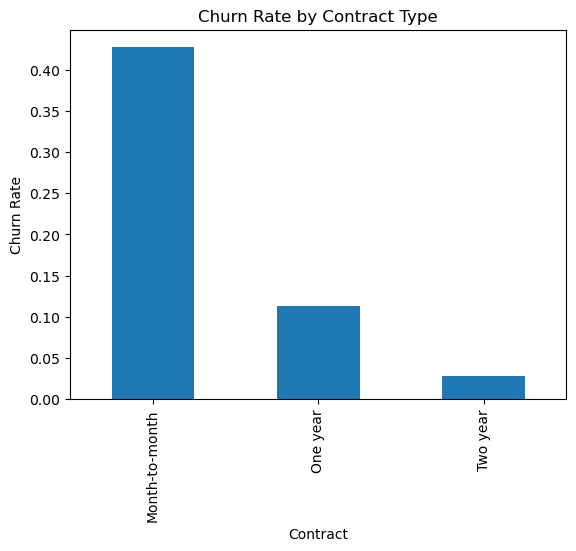

In [15]:
contract_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()


### 4.3 Churn by Tenure


In [16]:
df.groupby('Churn Value')['Tenure Months'].mean()


Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64

In [17]:
df['Tenure Bucket'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    right=False,
    labels=['0–11', '12–23', '24–35', '36–47', '48–59', '60–71']
)


In [18]:
tenure_churn = (
    df.groupby('Tenure Bucket')['Churn Value']
    .mean()
)
tenure_churn


C:\Users\Admin\AppData\Local\Temp\ipykernel_15236\1093070271.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure Bucket')['Churn Value']


Tenure Bucket
0–11     0.482842
12–23    0.295129
24–35    0.220320
36–47    0.195187
48–59    0.150000
60–71    0.082962
Name: Churn Value, dtype: float64

In [19]:
df.groupby('Churn Value')['Tenure Months'].mean()


Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64

In [20]:
tenure_churn


Tenure Bucket
0–11     0.482842
12–23    0.295129
24–35    0.220320
36–47    0.195187
48–59    0.150000
60–71    0.082962
Name: Churn Value, dtype: float64

In [21]:
df.groupby('Churn Value')['Monthly Charges'].mean()


Churn Value
0    61.265124
1    74.441332
Name: Monthly Charges, dtype: float64

### 4.4 Monthly Charges vs Churn


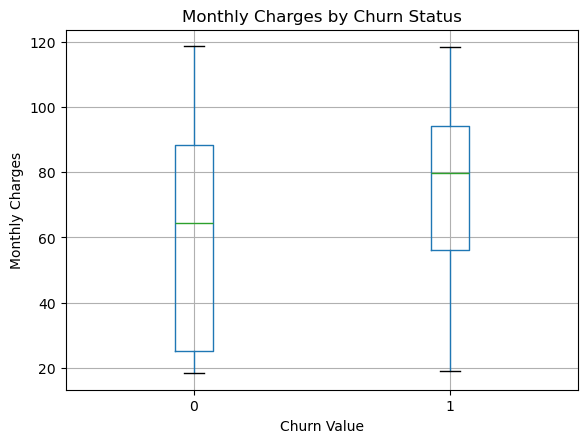

In [22]:


df.boxplot(column='Monthly Charges', by='Churn Value')
plt.title('Monthly Charges by Churn Status')
plt.suptitle('')
plt.ylabel('Monthly Charges')
plt.show()


In [23]:
high_risk_condition = (
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure Months'] < 12) &
    (df['Monthly Charges'] > df['Monthly Charges'].median())
)

df['High Risk Customer'] = high_risk_condition.astype(int)


In [24]:
df['High Risk Customer'].value_counts(normalize=True) * 100


High Risk Customer
0    89.067159
1    10.932841
Name: proportion, dtype: float64

In [25]:
df.groupby('Tenure Bucket', observed=False)['Churn Value'].mean()



Tenure Bucket
0–11     0.482842
12–23    0.295129
24–35    0.220320
36–47    0.195187
48–59    0.150000
60–71    0.082962
Name: Churn Value, dtype: float64

In [26]:
revenue_at_risk = df.loc[df['Churn Value'] == 1, 'Monthly Charges'].sum()
revenue_at_risk


np.float64(139130.85)

In [27]:
df['Churn Risk Score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) +
    (df['Tenure Months'] < 12).astype(int) +
    (df['Monthly Charges'] > df['Monthly Charges'].median()).astype(int)
)


In [28]:
df['Churn Risk Score'].value_counts().sort_index()


Churn Risk Score
0    1546
1    2305
2    2422
3     770
Name: count, dtype: int64

In [29]:
pd.crosstab(df['Churn Risk Score'], df['Churn Value'], normalize='index') * 100


Churn Value,0,1
Churn Risk Score,,
0,96.830530,3.169470
1,87.331887,12.668113
2,59.331131,40.668869
3,29.480519,70.519481


## 5. Exploratory Data Analysis using SQL

```sql
-- Overall churn distribution
SELECT
  Churn_Value,
  COUNT(*) AS customer_count,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM churn_data), 2) AS percentage
FROM churn_data
GROUP BY Churn_Value;

-- Churn rate by contract type
SELECT
  Contract,
  ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate
FROM churn_data
GROUP BY Contract
ORDER BY churn_rate DESC;

-- Churn rate by tenure bucket
SELECT
  CASE
    WHEN Tenure_Months < 12 THEN '0-11'
    WHEN Tenure_Months < 24 THEN '12-23'
    WHEN Tenure_Months < 36 THEN '24-35'
    WHEN Tenure_Months < 48 THEN '36-47'
    ELSE '48+'
  END AS tenure_bucket,
  ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate
FROM churn_data
GROUP BY tenure_bucket
ORDER BY churn_rate DESC;

-- Monthly revenue at risk due to churn
SELECT
  ROUND(SUM(Monthly_Charges), 2) AS revenue_at_risk
FROM churn_data
WHERE Churn_Value = 1;


## 6. Key Insights & Business Takeaways

- Month-to-month customers show significantly higher churn than long-term contracts  
- Early-tenure customers (0–12 months) are at the highest risk of churn  
- Higher monthly charges are associated with increased churn likelihood  
- Targeted retention strategies should focus on high-risk and early-stage customers
